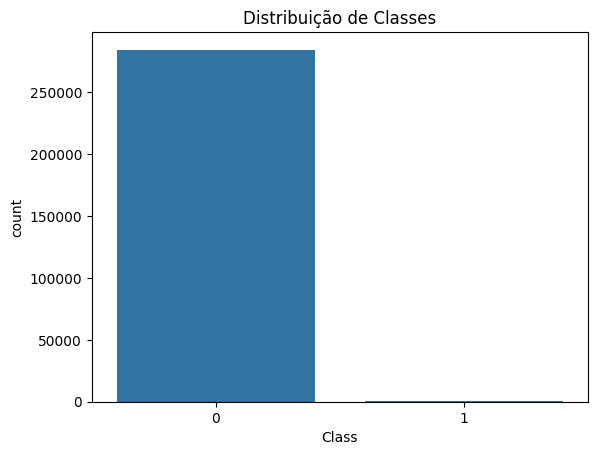

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../datasets/creditcard.csv', header=None)
# Definindo os nomes corretos das colunas 
# (V1-V28 são features PCA, Time, Amount e Class)
column_names =  ['Time'] + \
                [f'V{i}' for i in range(1, 29)] + \
                ['Amount', 'Class']
df.columns = column_names

sns.countplot(x='Class', data=df)
plt.title('Distribuição de Classes')
plt.show()
print(df['Class'].value_counts(normalize=True))

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Class', axis=1), 
    df['Class'], 
    test_size=0.3, 
    random_state=42, 
    stratify=df['Class']
)

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Score:", model.score(X_test, y_test))

Score: 0.9992509626300574


/home/francisco/projects/aulasml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
print("Score:", model.score(X_test, y_test))

Score: 0.9750945074494107


/home/francisco/projects/aulasml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


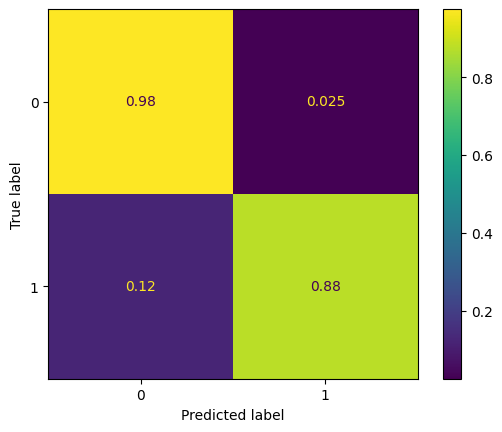

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, normalize='true')

In [17]:
from sklearn.metrics import classification_report
ypred = model.predict(X_test)
print(classification_report(y_test, ypred, digits=3))

              precision    recall  f1-score   support

           0      1.000     0.975     0.987     85295
           1      0.058     0.878     0.109       148

    accuracy                          0.975     85443
   macro avg      0.529     0.927     0.548     85443
weighted avg      0.998     0.975     0.986     85443



In [18]:
X, y = df.drop('Class', axis=1), df['Class']

In [21]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipe, X, y, scoring=['f1', 'roc_auc'], cv=cv)
print(scores)

{'fit_time': array([302.96673393, 287.72726297, 283.52407646, 304.93547606,
       303.45581174]), 'score_time': array([0.95331645, 0.57669663, 0.6187582 , 0.69883871, 0.53358841]), 'test_f1': array([0.82291667, 0.89473684, 0.88172043, 0.86170213, 0.85416667]), 'test_roc_auc': array([0.96329695, 0.9710861 , 0.97548628, 0.95936537, 0.96928116])}


In [23]:
from pprint import pprint
pprint(scores)

{'fit_time': array([302.96673393, 287.72726297, 283.52407646, 304.93547606,
       303.45581174]),
 'score_time': array([0.95331645, 0.57669663, 0.6187582 , 0.69883871, 0.53358841]),
 'test_f1': array([0.82291667, 0.89473684, 0.88172043, 0.86170213, 0.85416667]),
 'test_roc_auc': array([0.96329695, 0.9710861 , 0.97548628, 0.95936537, 0.96928116])}
